In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

emb_file = '/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/data/datasets/sup_con_oof_embeddings.csv'
RANDOM_STATE = 42
N_FOLDS = 5

In [2]:
# Load embeddings and prepare X, y
df = pd.read_csv(emb_file)
emb_cols = [c for c in df.columns if c.startswith("emb_")]
X = df[emb_cols].values
y_raw = df["label"].values

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_
n_classes = len(class_names)

print("Samples:", len(X), "| Features:", X.shape[1], "| Classes:", n_classes, list(class_names))
df["label"].value_counts().sort_index()

Samples: 1980 | Features: 1536 | Classes: 8 [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


label
0    120
1    384
2    312
3    120
4    306
5    168
6    186
7    384
Name: count, dtype: int64

In [3]:
# Scale features (recommended for LR, SVC, KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Define 5 classification models (pipelines where scaling is needed)
MODELS = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(C=10, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    ),
    "SVC": make_pipeline(
        StandardScaler(),
        SVC(C=10, kernel="rbf", class_weight="balanced", probability=True, gamma="scale", random_state=RANDOM_STATE),
    ),
    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=15, weights='distance',),
    ),
    "RandomForest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE),
    # "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}
# Use scaled X for all for fair comparison (RF/GB are scale-invariant but no harm)
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "f1_weighted", "f1_macro"]

In [6]:
# Run 5-fold cross-validation for each model
cv_results = {}
for name, model in MODELS.items():
    scores = cross_validate(model, X_scaled, y, cv=cv, scoring=scoring, return_train_score=False)
    cv_results[name] = {
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_weighted_mean": scores["test_f1_weighted"].mean(),
        "f1_weighted_std": scores["test_f1_weighted"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
    }
    print(f"{name}: accuracy={scores['test_accuracy'].mean():.4f} (±{scores['test_accuracy'].std():.4f})  "
          f"f1_weighted={scores['test_f1_weighted'].mean():.4f}  f1_macro={scores['test_f1_macro'].mean():.4f}")

LogisticRegression: accuracy=0.8490 (±0.0113)  f1_weighted=0.8487  f1_macro=0.8495
SVC: accuracy=0.9025 (±0.0175)  f1_weighted=0.9023  f1_macro=0.8973
KNN: accuracy=0.8227 (±0.0213)  f1_weighted=0.8215  f1_macro=0.8188
RandomForest: accuracy=0.5904 (±0.0187)  f1_weighted=0.5809  f1_macro=0.5595


In [7]:
# Compare models and select best by weighted F1
results_df = pd.DataFrame(cv_results).T
results_df = results_df.sort_values("f1_weighted_mean", ascending=False)
results_df

,accuracy_mean,accuracy_std,f1_weighted_mean,f1_weighted_std,f1_macro_mean,f1_macro_std
SVC,0.902525,0.017539,0.902310,0.017669,0.897300,0.017872
LogisticRegression,0.848990,0.011338,0.848709,0.011310,0.849452,0.014402
KNN,0.822727,0.021332,0.821531,0.022245,0.818826,0.024553
GradientBoosting,0.624242,0.025222,0.621000,0.023790,0.590243,0.018480
RandomForest,0.590404,0.018721,0.580879,0.019465,0.559459,0.022116


In [8]:
best_model_name = results_df.index[0]
print(f"Best model (by f1_weighted): {best_model_name}")

Best model (by f1_weighted): SVC


In [9]:
# Validate: train/test split, fit best model on train, evaluate on test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
clf = MODELS[best_model_name]
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Validation (80% train / 20% test)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 weighted:", f1_score(y_test, y_pred, average="weighted"))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))

Validation (80% train / 20% test)
Accuracy: 0.8964646464646465
F1 weighted: 0.8966232686624331
F1 macro: 0.8927297975931505


In [10]:
# Classification report (per-class precision, recall, F1)
print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names], zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.79      0.86        24
           1       1.00      0.99      0.99        77
           2       0.90      0.85      0.88        62
           3       0.88      0.96      0.92        24
           4       0.81      0.85      0.83        61
           5       0.94      0.88      0.91        34
           6       0.94      0.81      0.87        37
           7       0.83      0.94      0.88        77

    accuracy                           0.90       396
   macro avg       0.91      0.88      0.89       396
weighted avg       0.90      0.90      0.90       396



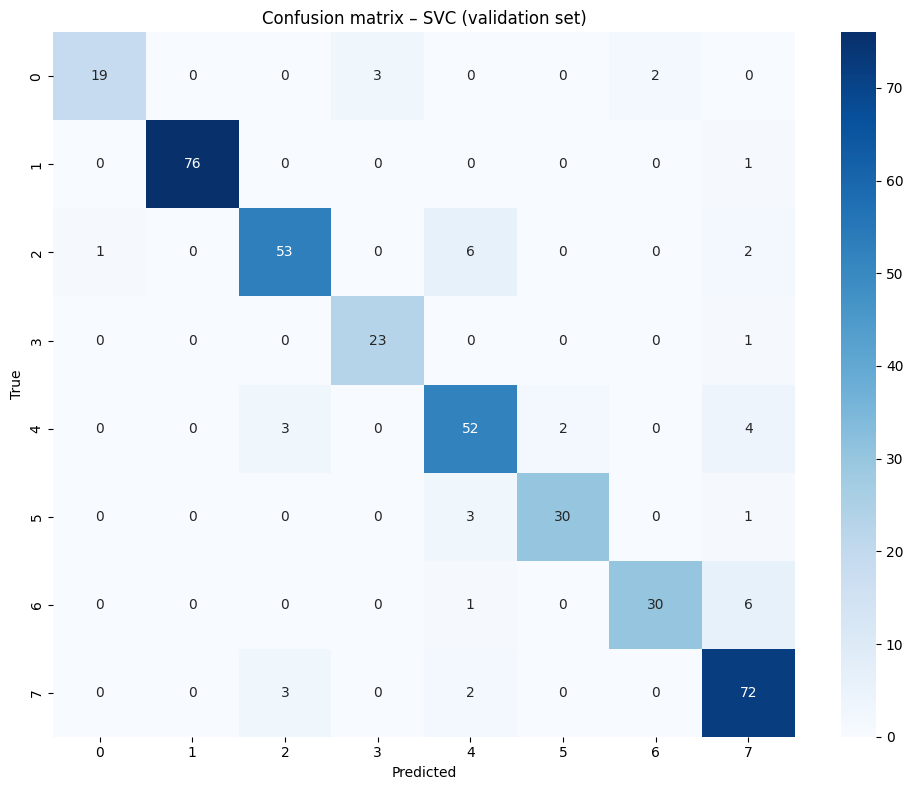

In [11]:
# Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix – {best_model_name} (validation set)")
plt.tight_layout()
plt.show()

In [12]:
# Save CV summary and validation metrics for records
out_dir = "/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/experiments-llm/results"
import os
os.makedirs(out_dir, exist_ok=True)
results_df.to_csv(f"{out_dir}/cv_embedding_classification_5fold.csv")
print(f"CV results saved to {out_dir}/cv_embedding_classification_5fold.csv")
validation_metrics = {
    "best_model": best_model_name,
    "accuracy": accuracy_score(y_test, y_pred),
    "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
    "f1_macro": f1_score(y_test, y_pred, average="macro"),
}
pd.Series(validation_metrics).to_csv(f"{out_dir}/validation_embedding_classification.csv", header=False)
print("Validation metrics saved to validation_embedding_classification.csv")

CV results saved to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/experiments-llm/results/cv_embedding_classification_5fold.csv
Validation metrics saved to validation_embedding_classification.csv
